# Эксперимент 3. Гибридный алгоритм

### Скачиваем данные

In [1]:
import pandas as pd
import numpy as np

model_data = pd.read_parquet("model_data_extended_ts.parquet")

print(model_data.shape)
model_data.head()

(1000000, 93)


,secret_id,rn,created_dt,max_turnover,max_turnover_clipped,log_target,log_income,finalincome,all_bki_current_pmt,all_tinkoff_current_pmt,...,log_income_growth_1,log_all_bki_current_pmt_delta_1,log_all_bki_current_pmt_growth_1,log_all_tinkoff_current_pmt_delta_1,log_all_tinkoff_current_pmt_growth_1,score_number_for_client,has_previous_score,has_2_previous_scores,days_since_prev_score,has_prev_score_dt
0,00000392ef72ab030b59cbfc1ec8fdfa,5,2025-12-08,1.203830e+06,1.203830e+06,14.001019,11.487618,97500,51391.54277,0.0,...,NaN,NaN,NaN,NaN,NaN,1,0,0,NaN,0
1,00000392ef72ab030b59cbfc1ec8fdfa,4,2025-12-21,1.133792e+06,1.133792e+06,13.941079,11.487618,97500,51391.54277,0.0,...,0.000000,0.000000,0.000000,0.0,0.0,2,1,0,13.0,1
2,00000392ef72ab030b59cbfc1ec8fdfa,3,2026-01-22,9.893660e+05,9.893660e+05,13.804821,11.609571,110146,13545.60000,0.0,...,0.009766,-1.333357,-0.112546,0.0,0.0,3,1,1,32.0,1
3,00000392ef72ab030b59cbfc1ec8fdfa,2,2026-02-23,8.226727e+05,8.226727e+05,13.620315,11.558109,104621,14384.89450,0.0,...,-0.004081,0.060113,0.005717,0.0,0.0,4,1,1,32.0,1
4,00000392ef72ab030b59cbfc1ec8fdfa,1,2026-05-02,1.902167e+06,1.902167e+06,14.458505,11.487618,97500,7160.00000,0.0,...,-0.005613,-0.697599,-0.065973,0.0,0.0,5,1,1,68.0,1


### Подготовка данных и базовые проверки корректности

In [2]:
pd.set_option('display.float_format', '{:.2f}'.format)
model_data.dtypes

,0
secret_id,object
rn,int64
created_dt,datetime64[ns]
max_turnover,float64
max_turnover_clipped,float64
...,...
score_number_for_client,int64
has_previous_score,int64
has_2_previous_scores,int64
days_since_prev_score,float64


### Визуализации для анализа результатов

1. Сравнение предсказаний и реальных значений (scatterplot)

In [3]:
import matplotlib.pyplot as plt
import numpy as np

def plot_actual_vs_predicted(y_true, y_pred, model_name="Model", alpha=0.05):
    plt.figure(figsize=(7, 7))
    plt.scatter(y_true, y_pred, alpha=alpha)

    min_val = min(np.min(y_true), np.min(y_pred))

    max_val = max(np.max(y_true), np.max(y_pred))

    plt.plot([min_val, max_val], [min_val, max_val])

    plt.xlabel("Actual log_target")
    plt.ylabel("Predicted log_target")

    plt.title(f"{model_name}: Actual vs Predicted")
    plt.show()


2. Сравнение распределений метрики 𝑦̂ и y.

In [4]:
def plot_prediction_distribution(y_true, y_pred, model_name="Model", bins=100):
    plt.figure(figsize=(12, 6))

    plt.hist(y_true, bins=bins, alpha=0.5, label="Actual")

    plt.hist(y_pred, bins=bins, alpha=0.5, label="Predicted")

    plt.xlabel("log_target")
    plt.ylabel("Count")

    plt.title(f"{model_name}: Prediction Distribution")

    plt.legend()
    plt.show()

3. Сравнение распределений метрики 𝑦̂ и y при 𝑦̂ > threshold

In [5]:
def plot_nonzero_distribution(y_true, y_pred=None, model_name="Model", bins=100, min_turnover=1000):
    threshold = np.log1p(min_turnover)
    true_mask = y_true > threshold
    plt.figure(figsize=(12, 6))

    # actual distribution
    plt.hist(y_true[true_mask], bins=bins, alpha=0.5, label="Actual non-zero")

    # predicted distribution
    if y_pred is not None:
        pred_mask = y_pred > threshold
        plt.hist(y_pred[pred_mask], bins=bins, alpha=0.5, label="Predicted non-zero")

    plt.xlabel("log_target")
    plt.ylabel("Count")
    plt.title(f"{model_name}: Non-zero Turnover Distribution")

    plt.legend()
    plt.show()

4. Сравнение распределений остатков 𝑦−𝑦̂

In [6]:
def plot_residual_distribution(y_true, y_pred, model_name="Model", bins=100):
    residuals = y_true - y_pred
    plt.figure(figsize=(12, 6))
    plt.hist(residuals, bins=bins)

    plt.xlabel("Residual")
    plt.ylabel("Count")
    plt.title(f"{model_name}: Residual Distribution")

    plt.show()

### Сбор выборки

#### Импортируем модель из эксперимента 2

In [8]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.4 MB/s eta 0:00:00


In [9]:
import numpy as np
import pandas as pd
import json

from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [10]:
with open("temporal_boosting_features.json", "r") as f:
    temporal_boosting_features = json.load(f)

with open("cat_features.json", "r") as f:
    cat_features = json.load(f)

temporal_catboost = CatBoostRegressor()
temporal_catboost.load_model("temporal_catboost.cbm")

CatBoostRegressor(depth=8, eval_metric='RMSE', iterations=2000, l2_leaf_reg=5, learning_rate=0.03, loss_function='RMSE', od_wait=200, random_seed=42, use_best_model=True, verbose=100)

#### Разбиваем выборку по аналогичному эксперименту 2 правилу

In [12]:
target = "log_target"

X = model_data[temporal_boosting_features].copy()
y = model_data[target].copy()
groups = model_data["secret_id"]

for col in cat_features:
    X[col] = X[col].fillna("missing").astype(str)

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

train_df = model_data.iloc[train_idx].copy()
test_df = model_data.iloc[test_idx].copy()

test_pool = Pool(X_test, y_test, cat_features=cat_features)

In [30]:
train_groups = train_df["secret_id"].reset_index(drop=True)

gss_val = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=43
)

inner_train_idx, val_idx = next(
    gss_val.split(
        train_df,
        train_df["log_target"],
        groups=train_groups
    )
)

inner_train_df = train_df.iloc[inner_train_idx].copy()
val_df = train_df.iloc[val_idx].copy()

X_val = X_train.iloc[val_idx].copy()
y_val = y_train.iloc[val_idx].copy()

val_pool = Pool(X_val, y_val, cat_features=cat_features)

### Сегментный алгоритм

In [13]:
segment_cols = [
    "log_income_bucket",
    "ip_flg",
    "company_age_bucket",
    "transaction_amt_is_null",
    "okved_cluster"
]

In [15]:
train_df = model_data.iloc[train_idx].copy()
test_df = model_data.iloc[test_idx].copy()

In [31]:
segment_table = (
    inner_train_df
    .groupby(segment_cols, observed=True)["log_target"]
    .agg(
        segment_pred_log="median",
        segment_size="size"
    )
    .reset_index()
)

global_segment_pred_log = inner_train_df["log_target"].median()

val_seg = val_df.merge(
    segment_table,
    on=segment_cols,
    how="left"
)

val_seg["segment_pred_log"] = (
    val_seg["segment_pred_log"]
    .fillna(global_segment_pred_log)
)

In [33]:
def build_segment_predictions(
    train_df,
    target_df,
    segment_cols,
    target="log_target"
):
    segment_table = (
        train_df
        .groupby(segment_cols, observed=True)[target]
        .agg(
            segment_pred_log="median",
            segment_size="size"
        )
        .reset_index()
    )

    global_segment_pred_log = train_df[target].median()

    target_seg = target_df.merge(
        segment_table,
        on=segment_cols,
        how="left"
    )

    target_seg["segment_pred_log"] = (
        target_seg["segment_pred_log"]
        .fillna(global_segment_pred_log)
    )

    target_seg["segment_size"] = (
        target_seg["segment_size"]
        .fillna(0)
    )

    return target_seg

### Сводим модели в единый пайплайн

#### Формула для модели: $$\hat{y}=y_{ml}\cdot I\left(\left|y_{ml}-y_{seg}\right|\le\tau\right)+\left(\alpha y_{ml}+\left(1-\alpha\right)y_{seg}\right)\cdot I\left(\left|y_{ml}-y_{seg}\right|>\tau\right)$$
Используем подбор гиперпараметров $α$ и $τ$ для поиска оптимальных значений. Для этого выделяем валидационную выборку и делаем подбор на ней.

Функция для подбора гиперпараметров

In [34]:
def threshold_hybrid_predict(
    y_ml_log,
    y_seg_log,
    alpha,
    tau
):
    diff = np.abs(y_ml_log - y_seg_log)

    y_hybrid_log = np.where(diff <= tau, y_ml_log, alpha * y_ml_log + (1 - alpha) * y_seg_log)
    return y_hybrid_log

Функция для подсчета метрик

In [35]:
def calc_metrics(
    y_true_log,
    y_pred_log
):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)

    mae_log = mean_absolute_error(y_true_log, y_pred_log)
    rmse_log = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
    r2_log = r2_score(y_true_log, y_pred_log)
    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    over_15 = (y_pred > 1.5 * np.maximum(y_true, 1)).mean()

    under_15 = (y_pred < y_true / 1.5).mean()

    return {
        "mae_log": mae_log,
        "rmse_log": rmse_log,
        "r2_log": r2_log,
        "mae": mae,
        "rmse": rmse,
        "over_15": over_15,
        "under_15": under_15
    }

In [36]:
train_groups = train_df["secret_id"].reset_index(drop=True)

gss_val = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=43
)

inner_train_idx, val_idx = next(
    gss_val.split(
        train_df,
        train_df[target],
        groups=train_groups
    )
)

inner_train_df = train_df.iloc[inner_train_idx].copy()
val_df = train_df.iloc[val_idx].copy()

X_val = X_train.iloc[val_idx].copy()
y_val = y_train.iloc[val_idx].copy()

val_pool = Pool(
    X_val,
    y_val,
    cat_features=cat_features
)

Получаем предсказания на валидационном датасете

In [38]:
val_seg = build_segment_predictions(
    train_df=inner_train_df,
    target_df=val_df,
    segment_cols=segment_cols,
    target=target
)

y_val_seg_log = val_seg["segment_pred_log"].values

upper_pred_log = model_data[target].quantile(0.999)

y_val_ml_log = temporal_catboost.predict(val_pool)
y_val_ml_log = np.clip(
    y_val_ml_log,
    0,
    upper_pred_log
)

y_val_true_log = val_df[target].values

Подбор гиперпараметров:

In [39]:
alphas = [0.5, 0.6, 0.7, 0.8, 0.9]
taus = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]

tuning_results = []

for alpha in alphas:
    for tau in taus:
        y_val_hybrid_log = threshold_hybrid_predict(
            y_ml_log=y_val_ml_log,
            y_seg_log=y_val_seg_log,
            alpha=alpha,
            tau=tau
        )

        metrics = calc_metrics(
            y_true_log=y_val_true_log,
            y_pred_log=y_val_hybrid_log
        )

        trigger_rate = (
            np.abs(y_val_ml_log - y_val_seg_log) > tau
        ).mean()

        tuning_results.append({
            "alpha": alpha,
            "tau": tau,
            "trigger_rate": trigger_rate,
            **metrics
        })

threshold_tuning_results = pd.DataFrame(tuning_results)

threshold_tuning_results.sort_values(
    "r2_log",
    ascending=False
).head(10)

,alpha,tau,trigger_rate,mae_log,rmse_log,r2_log,mae,rmse,over_15,under_15
29,0.90,3.00,0.56,4.51,5.41,0.34,1789823.67,7917472.83,0.44,0.46
28,0.90,2.50,0.66,4.50,5.41,0.34,1789198.62,7918448.75,0.44,0.46
27,0.90,2.00,0.75,4.49,5.41,0.34,1788715.11,7919584.49,0.44,0.46
26,0.90,1.50,0.83,4.48,5.41,0.34,1787756.87,7918666.41,0.44,0.46
25,0.90,1.00,0.90,4.48,5.41,0.34,1786405.73,7918113.87,0.43,0.46
24,0.90,0.50,0.95,4.48,5.41,0.34,1786010.90,7917858.97,0.43,0.46
23,0.80,3.00,0.56,4.49,5.45,0.33,1798428.80,7941757.23,0.44,0.46
22,0.80,2.50,0.66,4.47,5.45,0.33,1801923.07,7950024.81,0.44,0.46
21,0.80,2.00,0.75,4.46,5.45,0.33,1804712.38,7955843.10,0.44,0.46
20,0.80,1.50,0.83,4.45,5.45,0.33,1805224.02,7955192.50,0.44,0.46


Лучшие параметры

In [41]:
best_row = (
    threshold_tuning_results
    .sort_values("r2_log", ascending=False)
    .iloc[0]
)

best_alpha = float(best_row["alpha"])
best_tau = float(best_row["tau"])

print("Best alpha:", best_alpha)
print("Best tau:", best_tau)

Best alpha: 0.9
Best tau: 3.0


### Делаем предсказание на тестовой выборке

Предсказания ML-модели

In [46]:
y_test_ml_log = temporal_catboost.predict(test_pool)

y_test_ml_log = np.clip(
    y_test_ml_log,
    0,
    upper_pred_log
)

y_test_true_log = test_df[target].values

Предсказания сегментного алгоритма

In [43]:
test_seg = build_segment_predictions(
    train_df=train_df,
    target_df=test_df,
    segment_cols=segment_cols,
    target=target
)

y_test_seg_log = test_seg["segment_pred_log"].values

Результаты гибридного алгоритма

In [47]:
y_test_hybrid_log = threshold_hybrid_predict(
    y_ml_log=y_test_ml_log,
    y_seg_log=y_test_seg_log,
    alpha=best_alpha,
    tau=best_tau
)

Метрики:

In [48]:
hybrid_metrics = calc_metrics(
    y_true_log=y_test_true_log,
    y_pred_log=y_test_hybrid_log
)

ml_metrics = calc_metrics(
    y_true_log=y_test_true_log,
    y_pred_log=y_test_ml_log
)

seg_metrics = calc_metrics(
    y_true_log=y_test_true_log,
    y_pred_log=y_test_seg_log
)

In [49]:
print("Threshold Hybrid metrics in log-space")
print(f"alpha: {best_alpha}")
print(f"tau:   {best_tau}")

print(f"MAE log:  {hybrid_metrics['mae_log']:.4f}")
print(f"RMSE log: {hybrid_metrics['rmse_log']:.4f}")
print(f"R2 log:   {hybrid_metrics['r2_log']:.4f}")

print("\nThreshold Hybrid metrics in original scale")
print(f"MAE:  {hybrid_metrics['mae']:,.2f}")
print(f"RMSE: {hybrid_metrics['rmse']:,.2f}")

print("\nBusiness metrics")
print(f"Overestimation > 1.5x:  {hybrid_metrics['over_15']:.2%}")
print(f"Underestimation > 1.5x: {hybrid_metrics['under_15']:.2%}")

Threshold Hybrid metrics in log-space
alpha: 0.9
tau:   3.0
MAE log:  4.4955
RMSE log: 5.4024
R2 log:   0.3375

Threshold Hybrid metrics in original scale
MAE:  1,741,860.23
RMSE: 7,807,661.93

Business metrics
Overestimation > 1.5x:  43.77%
Underestimation > 1.5x: 45.88%


Сравнение

In [50]:
comparison = pd.DataFrame([
    {
        "model": "Segment",
        **seg_metrics
    },
    {
        "model": "Temporal CatBoost",
        **ml_metrics
    },
    {
        "model": "Threshold Hybrid",
        **hybrid_metrics
    }
])

comparison

,model,mae_log,rmse_log,r2_log,mae,rmse,over_15,under_15
0,Segment,4.43,6.77,-0.04,1923724.59,8006394.73,0.31,0.41
1,Temporal CatBoost,4.51,5.38,0.34,1739091.40,7796200.74,0.44,0.46
2,Threshold Hybrid,4.50,5.40,0.34,1741860.23,7807661.93,0.44,0.46


In [51]:
test_diff = np.abs(y_test_ml_log - y_test_seg_log)

trigger_rate_test = (test_diff > best_tau).mean()

print(
    f"Hybrid correction activated: "
    f"{trigger_rate_test:.2%}"
)

Hybrid correction activated: 55.56%


То есть, гибридный алгоритм добавлялся в 55% предсказаний.

Как часто расходились значения алгоритмов?

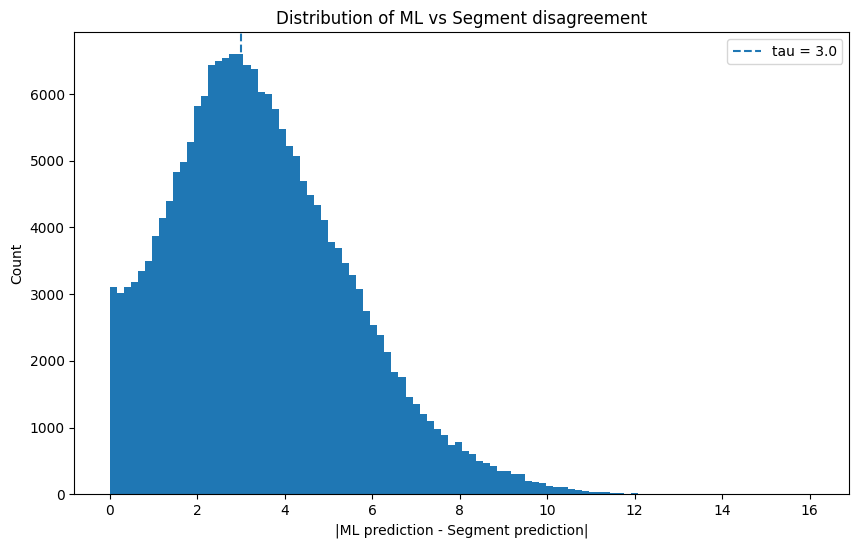

In [52]:
plt.figure(figsize=(10, 6))

plt.hist(
    test_diff,
    bins=100
)

plt.axvline(
    best_tau,
    linestyle="--",
    label=f"tau = {best_tau}"
)

plt.xlabel("|ML prediction - Segment prediction|")
plt.ylabel("Count")
plt.title("Distribution of ML vs Segment disagreement")
plt.legend()

plt.show()

Графики качества

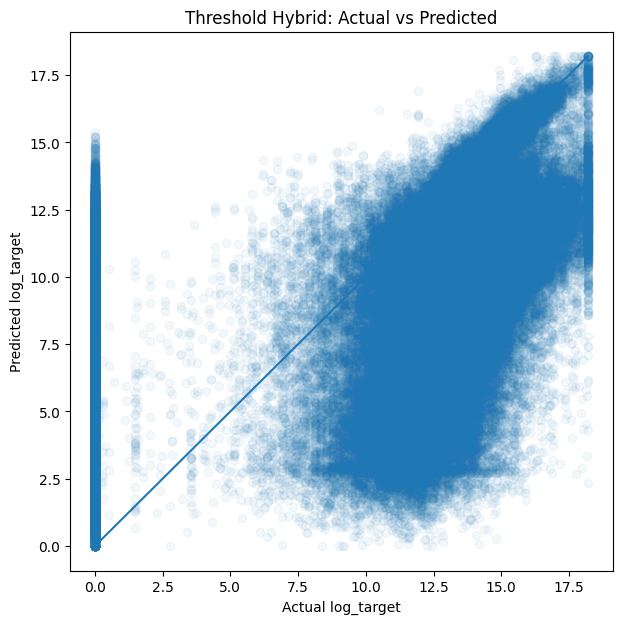

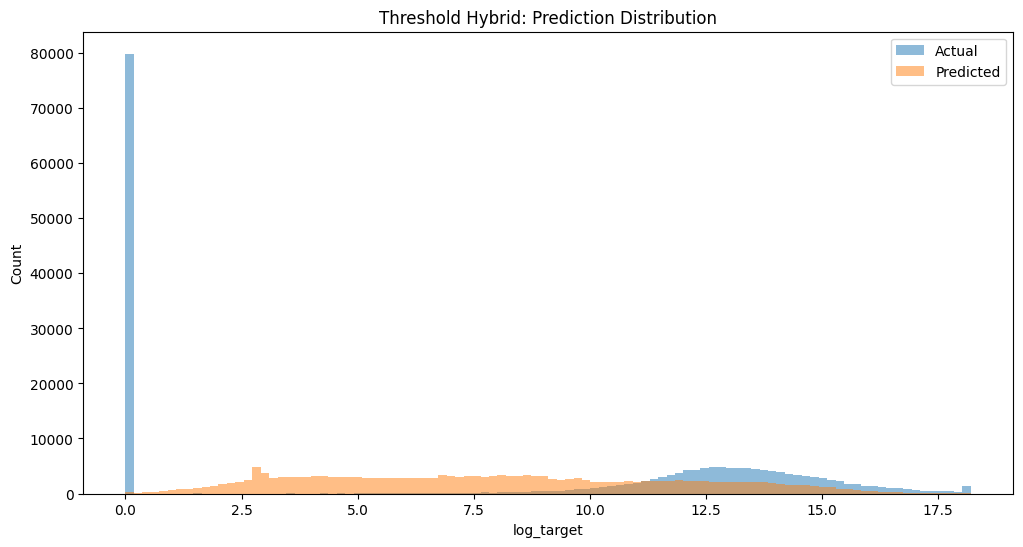

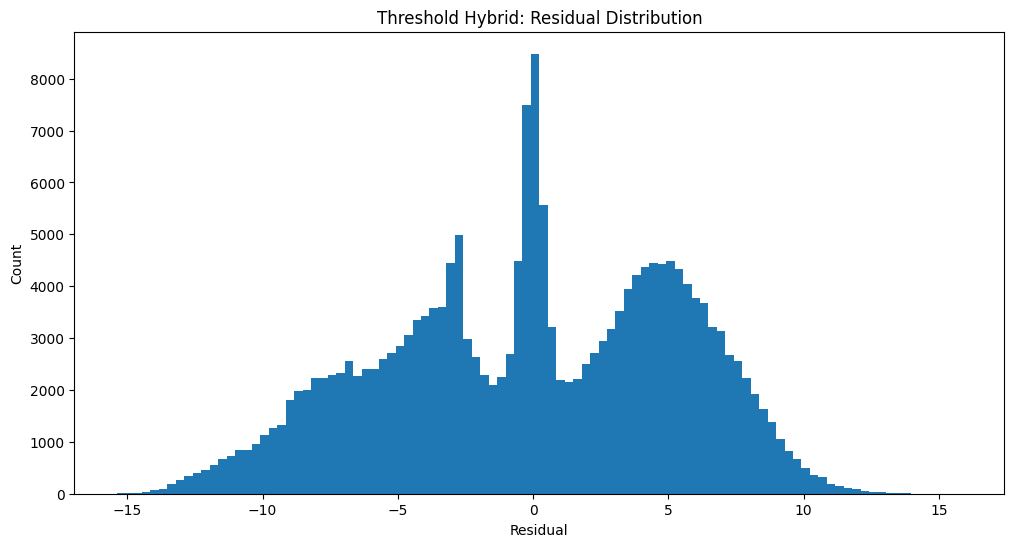

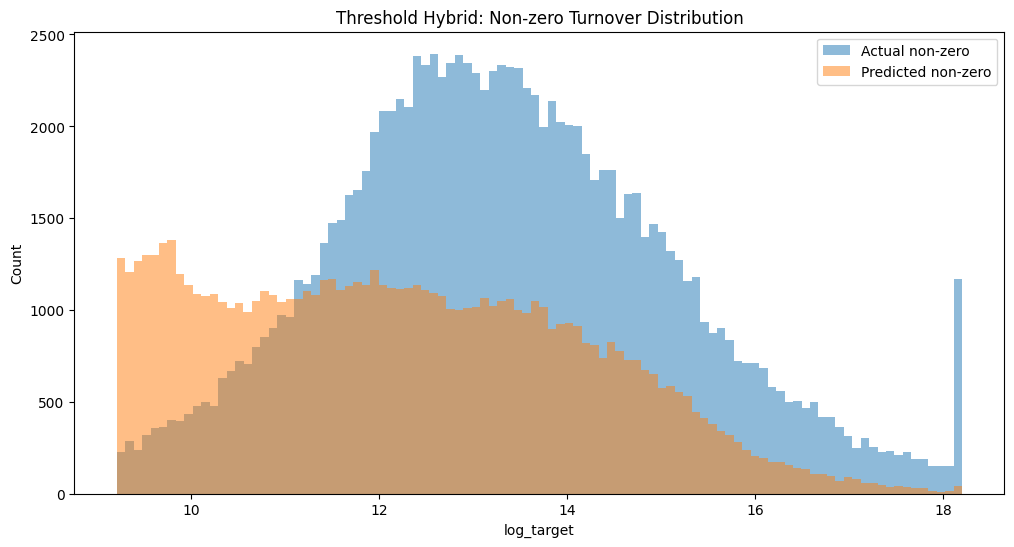

In [53]:
plot_actual_vs_predicted(
    y_test_true_log,
    y_test_hybrid_log,
    model_name="Threshold Hybrid"
)

plot_prediction_distribution(
    y_test_true_log,
    y_test_hybrid_log,
    model_name="Threshold Hybrid"
)

plot_residual_distribution(
    y_test_true_log,
    y_test_hybrid_log,
    model_name="Threshold Hybrid"
)

plot_nonzero_distribution(
    y_test_true_log,
    y_test_hybrid_log,
    model_name="Threshold Hybrid",
    min_turnover=10000
)

### Выводы

Эксперимент показал, что threshold hybrid algorithm не дал существенного улучшения относительно Temporal CatBoost. Лучшие параметры (\alpha=0.9, \tau=3.0) означают, что модель в большинстве случаев сохраняет высокий уровень доверия к индивидуальному ML-прогнозу и лишь незначительно корректирует его сегментной оценкой.

При этом hybrid correction активировался более чем в 55% наблюдений, однако это не привело к заметному улучшению ни quality-метрик, ни business-метрик. Полученные результаты показывают, что Temporal CatBoost уже достаточно эффективно учитывает индивидуальные особенности клиентов, а дополнительное сглаживание через сегментный prior в данной постановке задачи практически не повышает качество прогнозирования.

В то же время эксперимент подтвердил устойчивость temporal ML-подхода: даже при активном вмешательстве сегментной оценки итоговые метрики изменяются незначительно.